In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='paper', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150

DOWNLOADS = Path(r"C:\Users\USER\Downloads")


In [3]:
# ── File registry ──────────────────────────────────────────────────────────────
# Each entry: (file_path, model_name, judge_name, condition, judge_type)

FILE_REGISTRY = [

    # ── GLM-5.1 Accuracy ──
    (DOWNLOADS / "llama8b_glmjudge_0shot.csv",           "Llama-8B-DSK", "GLM-5.1", "0-shot", "accuracy"),
    (DOWNLOADS / "llama8b_glmjudge_1shot.csv",           "Llama-8B-DSK", "GLM-5.1", "1-shot", "accuracy"),
    (DOWNLOADS / "medgemma_glmjudge_0shot.csv",          "MedGemma",     "GLM-5.1", "0-shot", "accuracy"),
    (DOWNLOADS / "medgemma_glmjudge_1shot.csv",          "MedGemma",     "GLM-5.1", "1-shot", "accuracy"),
    (DOWNLOADS / "qwen_glmjudge_0shot.csv",              "Qwen-3.6",     "GLM-5.1", "0-shot", "accuracy"),
    (DOWNLOADS / "qwen_glmjudge_1shot.csv",              "Qwen-3.6",     "GLM-5.1", "1-shot", "accuracy"),

    # ── DeepSeek Accuracy ──
    (DOWNLOADS / "llama8b_judge_0shot.csv",              "Llama-8B-DSK", "DeepSeek", "0-shot", "accuracy"),
    (DOWNLOADS / "llama8b_judge_1shot.csv",              "Llama-8B-DSK", "DeepSeek", "1-shot", "accuracy"),
    (DOWNLOADS / "medgemma_judgedsk_0shot.csv",          "MedGemma",     "DeepSeek", "0-shot", "accuracy"),
    (DOWNLOADS / "medgemma_judgedsk_1shot.csv",          "MedGemma",     "DeepSeek", "1-shot", "accuracy"),
    (DOWNLOADS / "qwen3_6_judge_0shot.csv",              "Qwen-3.6",     "DeepSeek", "0-shot", "accuracy"),
    (DOWNLOADS / "qwen3_6_judge_1shot.csv",              "Qwen-3.6",     "DeepSeek", "1-shot", "accuracy"),

    # ── GLM-5.1 Reasoning ──
    (DOWNLOADS / "llama8b_glmjudge_negated_hx.csv",         "Llama-8B-DSK", "GLM-5.1", "negated_hx",        "reasoning"),
    (DOWNLOADS / "llama8b_glmjudge_negated_ruled_out.csv",   "Llama-8B-DSK", "GLM-5.1", "negated_ruled_out", "reasoning"),
    (DOWNLOADS / "llama8b_glmjudge_negated_hedge.csv",       "Llama-8B-DSK", "GLM-5.1", "negated_hedge",     "reasoning"),
    (DOWNLOADS / "llama8b_glmjudge_random_masked.csv",       "Llama-8B-DSK", "GLM-5.1", "random_masked",     "reasoning"),
    (DOWNLOADS / "llama8b_glmjudge_counterfactual.csv",      "Llama-8B-DSK", "GLM-5.1", "counterfactual",    "reasoning"),
    (DOWNLOADS / "medgemma_glmjudge_negated_hx.csv",         "MedGemma",     "GLM-5.1", "negated_hx",        "reasoning"),
    (DOWNLOADS / "medgemma_glmjudge_negated_ruled_out.csv",  "MedGemma",     "GLM-5.1", "negated_ruled_out", "reasoning"),
    (DOWNLOADS / "medgemma_glmjudge_negated_hedge.csv",      "MedGemma",     "GLM-5.1", "negated_hedge",     "reasoning"),
    (DOWNLOADS / "medgemma_glmjudge_random_masked.csv",      "MedGemma",     "GLM-5.1", "random_masked",     "reasoning"),
    (DOWNLOADS / "medgemma_glmjudge_counterfactual.csv",     "MedGemma",     "GLM-5.1", "counterfactual",    "reasoning"),
    (DOWNLOADS / "qwen36_glmjudge_negated_hx.csv",           "Qwen-3.6",     "GLM-5.1", "negated_hx",        "reasoning"),
    (DOWNLOADS / "qwen36_glmjudge_negated_ruled_out.csv",    "Qwen-3.6",     "GLM-5.1", "negated_ruled_out", "reasoning"),
    (DOWNLOADS / "qwen36_glmjudge_negated_hedge.csv",        "Qwen-3.6",     "GLM-5.1", "negated_hedge",     "reasoning"),
    (DOWNLOADS / "qwen36_glmjudge_random_masked.csv",        "Qwen-3.6",     "GLM-5.1", "random_masked",     "reasoning"),
    (DOWNLOADS / "qwen36_glmjudge_counterfactual.csv",       "Qwen-3.6",     "GLM-5.1", "counterfactual",    "reasoning"),

    # ── DeepSeek Reasoning ──
    (DOWNLOADS / "llama8b_judge_negated_hx.csv",          "Llama-8B-DSK", "DeepSeek", "negated_hx",        "reasoning"),
    (DOWNLOADS / "llama8b_judge_negated_ruled_out.csv",   "Llama-8B-DSK", "DeepSeek", "negated_ruled_out", "reasoning"),
    (DOWNLOADS / "llama8b_judge_negated_hedge.csv",       "Llama-8B-DSK", "DeepSeek", "negated_hedge",     "reasoning"),
    (DOWNLOADS / "llama8b_judge_random_masked.csv",       "Llama-8B-DSK", "DeepSeek", "random_masked",     "reasoning"),
    (DOWNLOADS / "llama8b_judge_counterfactual.csv",      "Llama-8B-DSK", "DeepSeek", "counterfactual",    "reasoning"),
    (DOWNLOADS / "medgemma_judge_negated_hx.csv",         "MedGemma",     "DeepSeek", "negated_hx",        "reasoning"),
    (DOWNLOADS / "medgemma_judge_negated_ruled_out.csv",  "MedGemma",     "DeepSeek", "negated_ruled_out", "reasoning"),
    (DOWNLOADS / "medgemma_judge_negated_hedge.csv",      "MedGemma",     "DeepSeek", "negated_hedge",     "reasoning"),
    (DOWNLOADS / "medgemma_judge_random_masked.csv",      "MedGemma",     "DeepSeek", "random_masked",     "reasoning"),
    (DOWNLOADS / "medgemma_judge_counterfactual.csv",     "MedGemma",     "DeepSeek", "counterfactual",    "reasoning"),
    (DOWNLOADS / "qwen36_judge_negated_hx.csv",           "Qwen-3.6",     "DeepSeek", "negated_hx",        "reasoning"),
    (DOWNLOADS / "qwen36_judge_negated_ruled_out.csv",    "Qwen-3.6",     "DeepSeek", "negated_ruled_out", "reasoning"),
    (DOWNLOADS / "qwen36_judge_negated_hedge.csv",        "Qwen-3.6",     "DeepSeek", "negated_hedge",     "reasoning"),
    (DOWNLOADS / "qwen36_judge_random_masked.csv",        "Qwen-3.6",     "DeepSeek", "random_masked",     "reasoning"),
    (DOWNLOADS / "qwen36_judge_counterfactual.csv",       "Qwen-3.6",     "DeepSeek", "counterfactual",    "reasoning"),
]

# ── Load all files into one big DataFrame ─────────────────────────────────────
def load_all_files(registry):
    frames = []
    for path, model, judge, condition, jtype in registry:
        if not path.exists():
            print(f"  MISSING: {path.name}")
            continue
        df = pd.read_csv(path)
        df['model']      = model
        df['judge']      = judge
        df['condition']  = condition
        df['judge_type'] = jtype

        # GLM uses 'hallucination_detected' (True/False boolean)
        # DSK uses 'hallucination_type' (string — "none" means no hallucination)
        # Normalize both to a single boolean column called hallucination_flag
        if 'hallucination_detected' in df.columns:
            df['hallucination_flag'] = df['hallucination_detected'].astype(bool)
        elif 'hallucination_type' in df.columns:
            df['hallucination_flag'] = df['hallucination_type'] != 'none'
        else:
            df['hallucination_flag'] = False

        frames.append(df)

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


df_all    = load_all_files(FILE_REGISTRY)
df_acc    = df_all[df_all['judge_type'] == 'accuracy'].copy()
df_reason = df_all[df_all['judge_type'] == 'reasoning'].copy()

MODEL_ORDER = ['Llama-8B-DSK', 'MedGemma', 'Qwen-3.6']

print(f"Loaded {len(df_all)} total rows")
print(f"  Accuracy  : {len(df_acc)} rows")
print(f"  Reasoning : {len(df_reason)} rows")


Loaded 210 total rows
  Accuracy  : 60 rows
  Reasoning : 150 rows


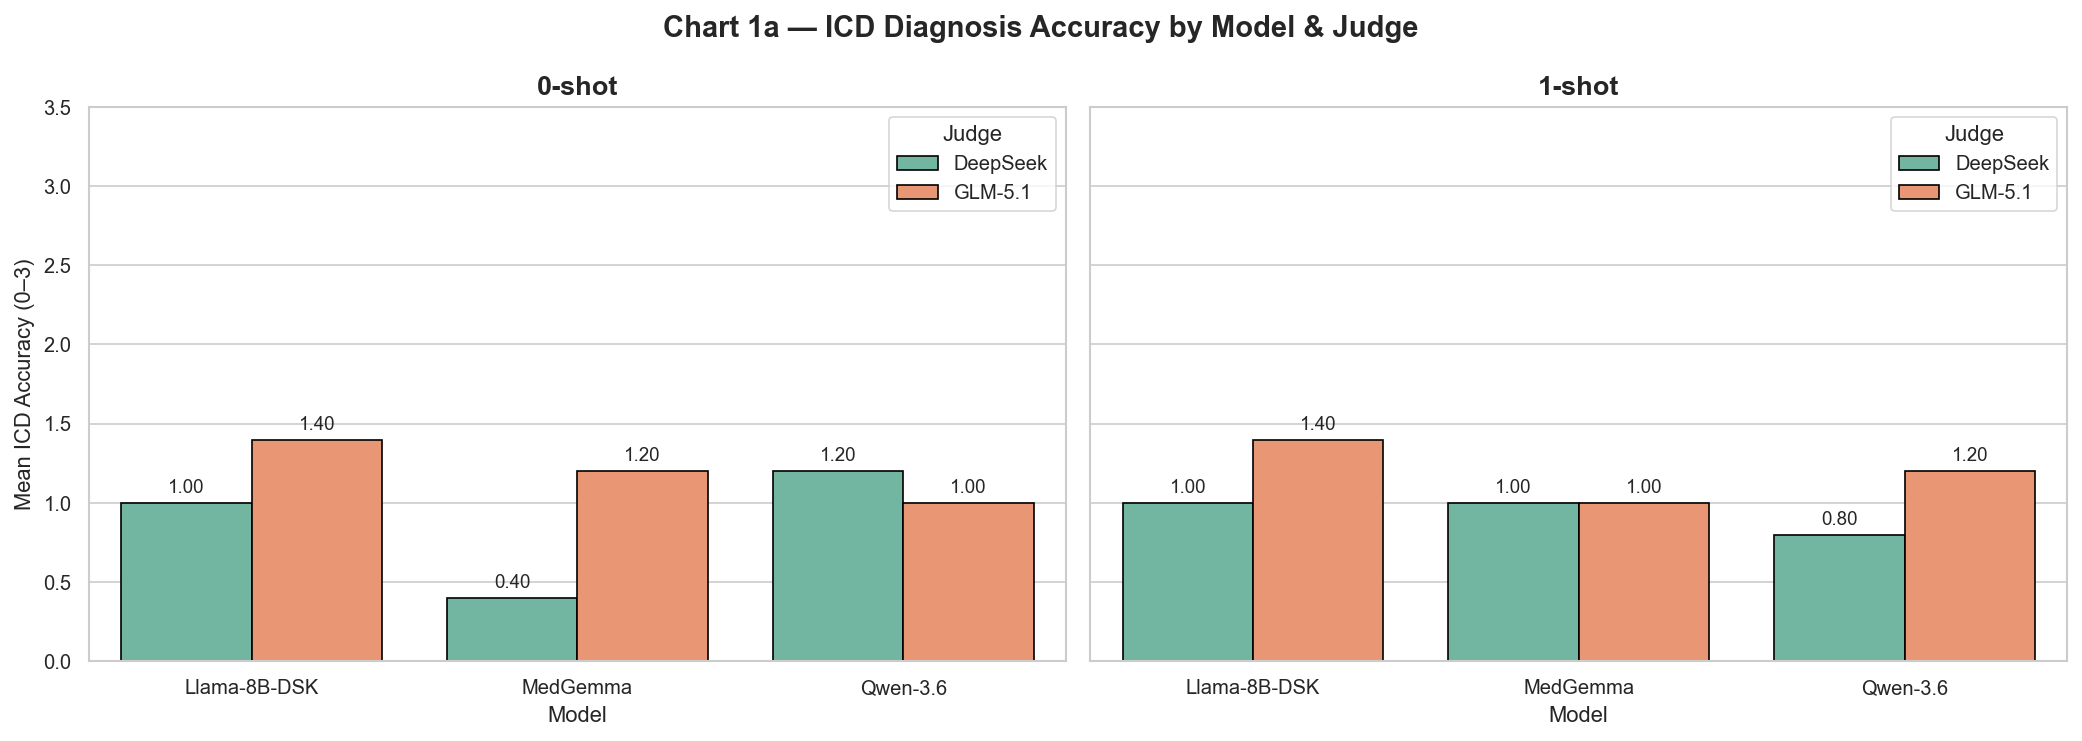

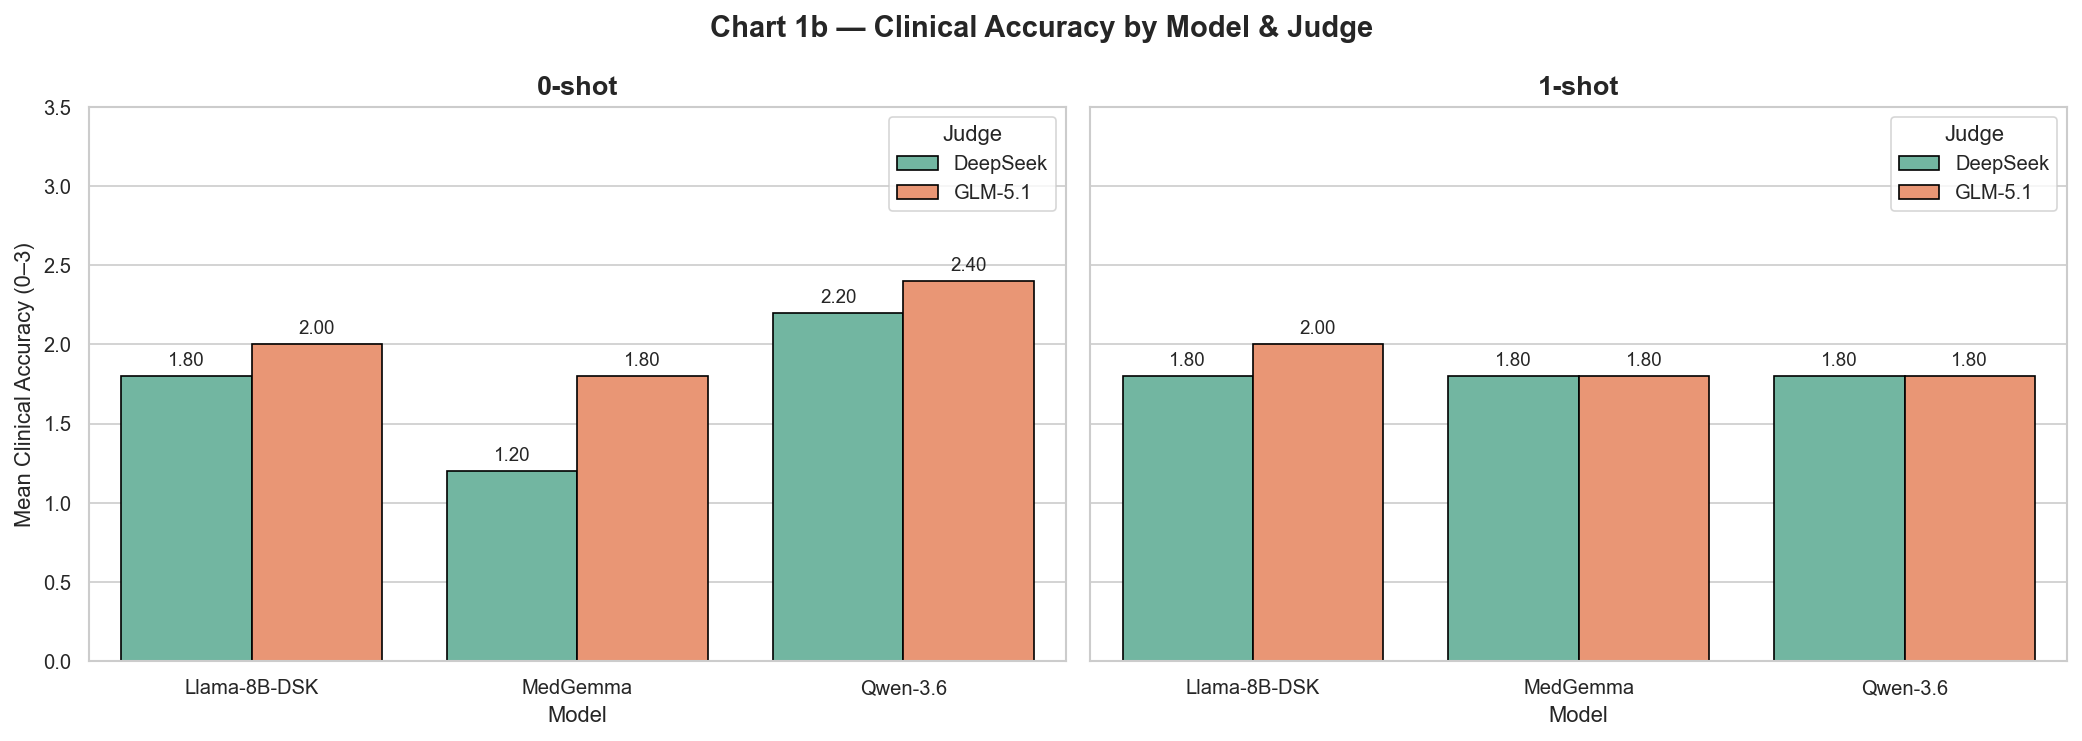

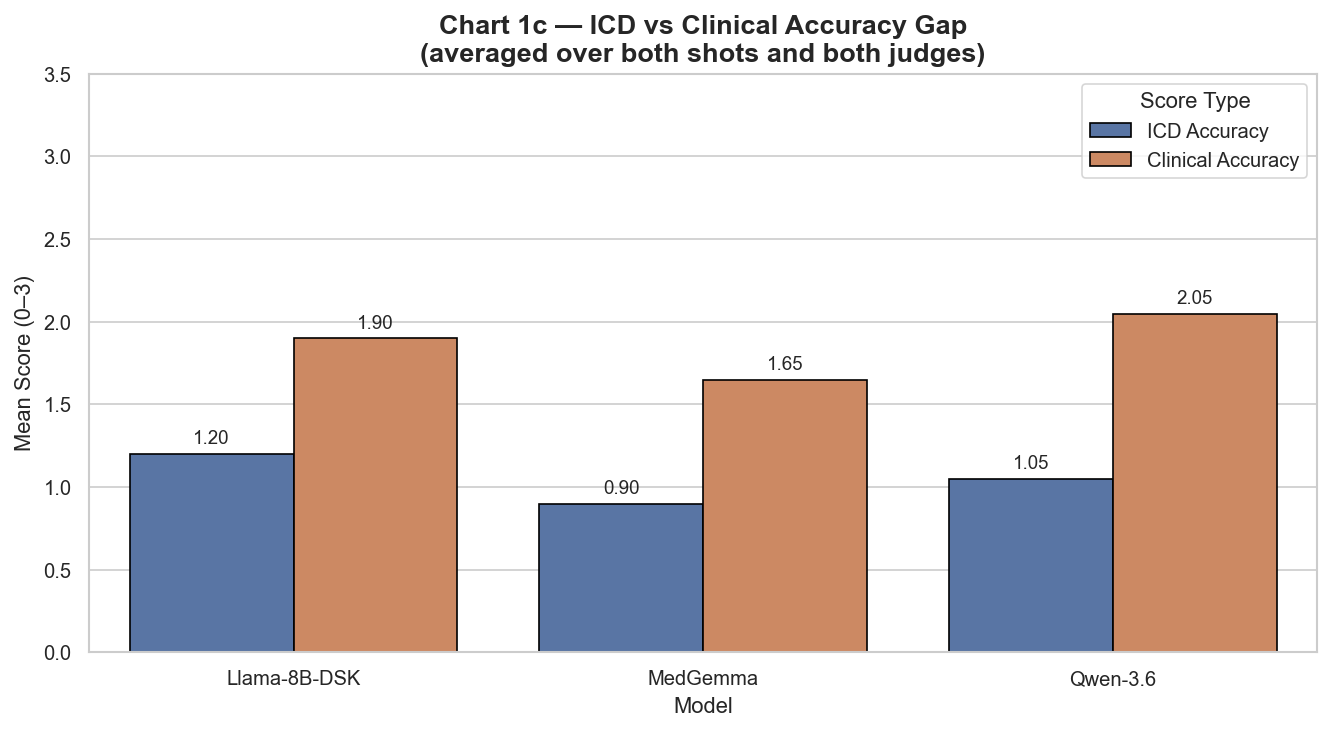

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# Chart 1: Accuracy Comparison
# ═══════════════════════════════════════════════════════════════════════════════

# Keep only rows where ICD score is a valid number (0 to 3)
df_acc_clean = df_acc[df_acc['d1_icd_accuracy'].between(0, 3)].copy()

# Average ICD and Clinical scores per (model, judge, shot condition)
acc_avg = (
    df_acc_clean
    .groupby(['model', 'judge', 'condition'])[['d1_icd_accuracy', 'd1_clinical_accuracy']]
    .mean()
    .reset_index()
)

# ── 1a: ICD Accuracy — 0-shot vs 1-shot side by side ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, shot in zip(axes, ['0-shot', '1-shot']):
    sub = acc_avg[acc_avg['condition'] == shot]
    sns.barplot(data=sub, x='model', y='d1_icd_accuracy', hue='judge',
                order=MODEL_ORDER, palette='Set2', edgecolor='black', ax=ax)
    ax.set_title(f'{shot}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Mean ICD Accuracy (0–3)')
    ax.set_xlabel('Model')
    ax.set_ylim(0, 3.5)
    ax.legend(title='Judge')
    for bar_group in ax.containers:
        ax.bar_label(bar_group, fmt='%.2f', padding=3, fontsize=9)

fig.suptitle('Chart 1a — ICD Diagnosis Accuracy by Model & Judge', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 1b: Clinical Accuracy — 0-shot vs 1-shot side by side ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, shot in zip(axes, ['0-shot', '1-shot']):
    sub = acc_avg[acc_avg['condition'] == shot]
    sns.barplot(data=sub, x='model', y='d1_clinical_accuracy', hue='judge',
                order=MODEL_ORDER, palette='Set2', edgecolor='black', ax=ax)
    ax.set_title(f'{shot}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Mean Clinical Accuracy (0–3)')
    ax.set_xlabel('Model')
    ax.set_ylim(0, 3.5)
    ax.legend(title='Judge')
    for bar_group in ax.containers:
        ax.bar_label(bar_group, fmt='%.2f', padding=3, fontsize=9)

fig.suptitle('Chart 1b — Clinical Accuracy by Model & Judge', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 1c: ICD vs Clinical gap — averaged over all shots and judges ──────────────
# Shows which models score higher on ICD vs clinical phrasing (or vice versa)
gap_avg = df_acc_clean.groupby('model')[['d1_icd_accuracy', 'd1_clinical_accuracy']].mean().reset_index()

# Reshape from wide to long so seaborn can draw two bars per model
gap_long = gap_avg.melt(id_vars='model', var_name='score_type', value_name='score')
gap_long['score_type'] = gap_long['score_type'].map({
    'd1_icd_accuracy':      'ICD Accuracy',
    'd1_clinical_accuracy': 'Clinical Accuracy',
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=gap_long, x='model', y='score', hue='score_type',
            order=MODEL_ORDER, palette=['#4C72B0', '#DD8452'], edgecolor='black', ax=ax)
ax.set_title('Chart 1c — ICD vs Clinical Accuracy Gap\n(averaged over both shots and both judges)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Score (0–3)')
ax.set_xlabel('Model')
ax.set_ylim(0, 3.5)
ax.legend(title='Score Type')
for bar_group in ax.containers:
    ax.bar_label(bar_group, fmt='%.2f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()


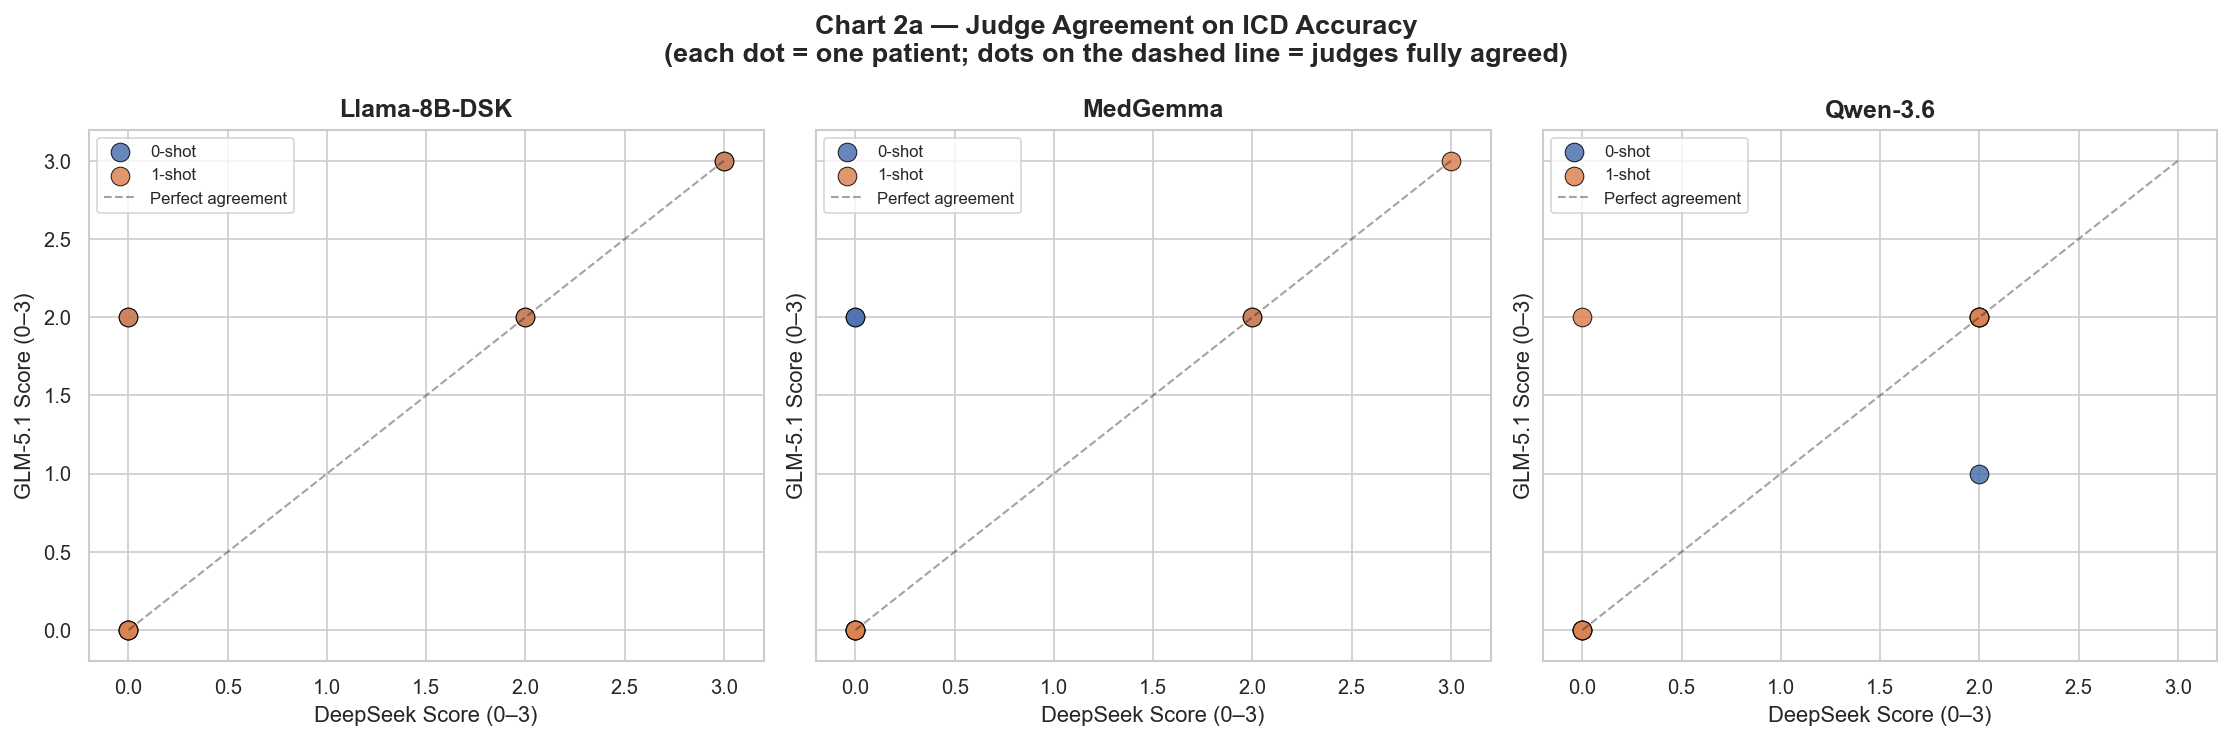

C:\Users\USER\AppData\Local\Temp\ipykernel_50244\1501485380.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diff_avg, x='model', y='abs_diff',


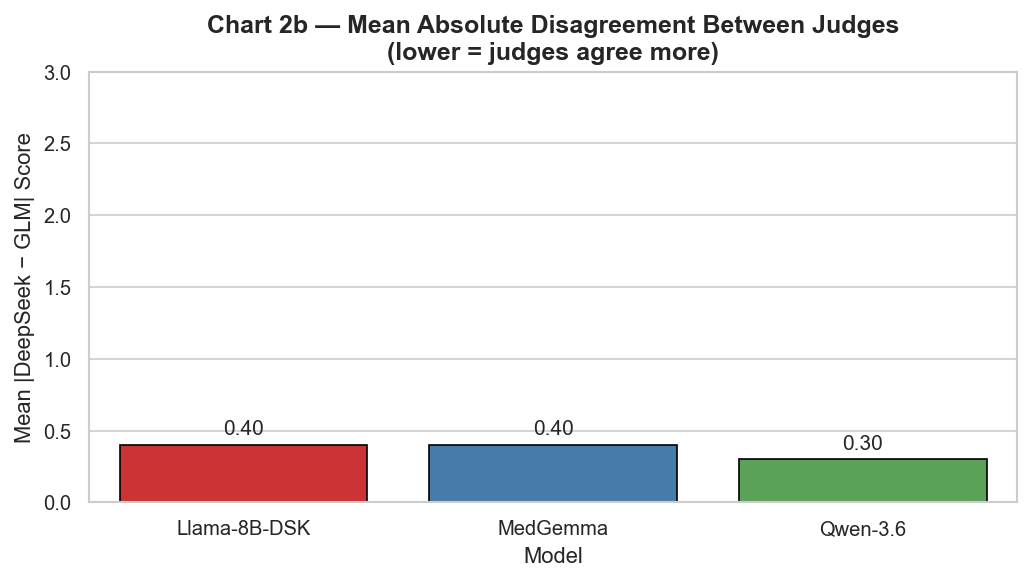

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# Chart 2: Judge Agreement — how much do DeepSeek and GLM-5.1 agree?
# ═══════════════════════════════════════════════════════════════════════════════

# Keep only valid ICD scores
df_acc_clean = df_acc[df_acc['d1_icd_accuracy'].between(0, 3)].copy()

# Separate into two tables — one per judge
df_dsk = df_acc_clean[df_acc_clean['judge'] == 'DeepSeek'][['model', 'condition', 'HADM_ID', 'd1_icd_accuracy']]
df_glm = df_acc_clean[df_acc_clean['judge'] == 'GLM-5.1'][['model', 'condition', 'HADM_ID', 'd1_icd_accuracy']]

df_dsk = df_dsk.rename(columns={'d1_icd_accuracy': 'dsk_score'})
df_glm = df_glm.rename(columns={'d1_icd_accuracy': 'glm_score'})

# Join on the same patient (HADM_ID), model, and shot condition
df_agree = pd.merge(df_dsk, df_glm, on=['model', 'condition', 'HADM_ID'])

# ── 2a: Scatter — one dot per patient, per model subplot ─────────────────────
# Dots on the diagonal = both judges gave the same score
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
dot_colors = {'0-shot': '#4C72B0', '1-shot': '#DD8452'}

for ax, model in zip(axes, MODEL_ORDER):
    sub = df_agree[df_agree['model'] == model]
    if sub.empty:
        ax.set_visible(False)
        continue
    for shot in ['0-shot', '1-shot']:
        shot_sub = sub[sub['condition'] == shot]
        ax.scatter(shot_sub['dsk_score'], shot_sub['glm_score'],
                   color=dot_colors[shot], label=shot,
                   s=80, alpha=0.85, edgecolors='black', linewidths=0.5)
    # Dashed diagonal = perfect agreement between judges
    ax.plot([0, 3], [0, 3], 'k--', linewidth=1, alpha=0.4, label='Perfect agreement')
    ax.set_title(model, fontsize=12, fontweight='bold')
    ax.set_xlabel('DeepSeek Score (0–3)')
    ax.set_ylabel('GLM-5.1 Score (0–3)')
    ax.set_xlim(-0.2, 3.2)
    ax.set_ylim(-0.2, 3.2)
    ax.legend(fontsize=8)

fig.suptitle('Chart 2a — Judge Agreement on ICD Accuracy\n(each dot = one patient; dots on the dashed line = judges fully agreed)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2b: Mean absolute disagreement per model ──────────────────────────────────
# Lower bar = judges agree more with each other
df_agree['abs_diff'] = (df_agree['dsk_score'] - df_agree['glm_score']).abs()
diff_avg = df_agree.groupby('model')['abs_diff'].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=diff_avg, x='model', y='abs_diff',
            order=MODEL_ORDER, palette='Set1', edgecolor='black', ax=ax)
ax.set_title('Chart 2b — Mean Absolute Disagreement Between Judges\n(lower = judges agree more)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Mean |DeepSeek − GLM| Score')
ax.set_xlabel('Model')
ax.set_ylim(0, 3)
for bar_group in ax.containers:
    ax.bar_label(bar_group, fmt='%.2f', padding=3, fontsize=10)
plt.tight_layout()
plt.show()


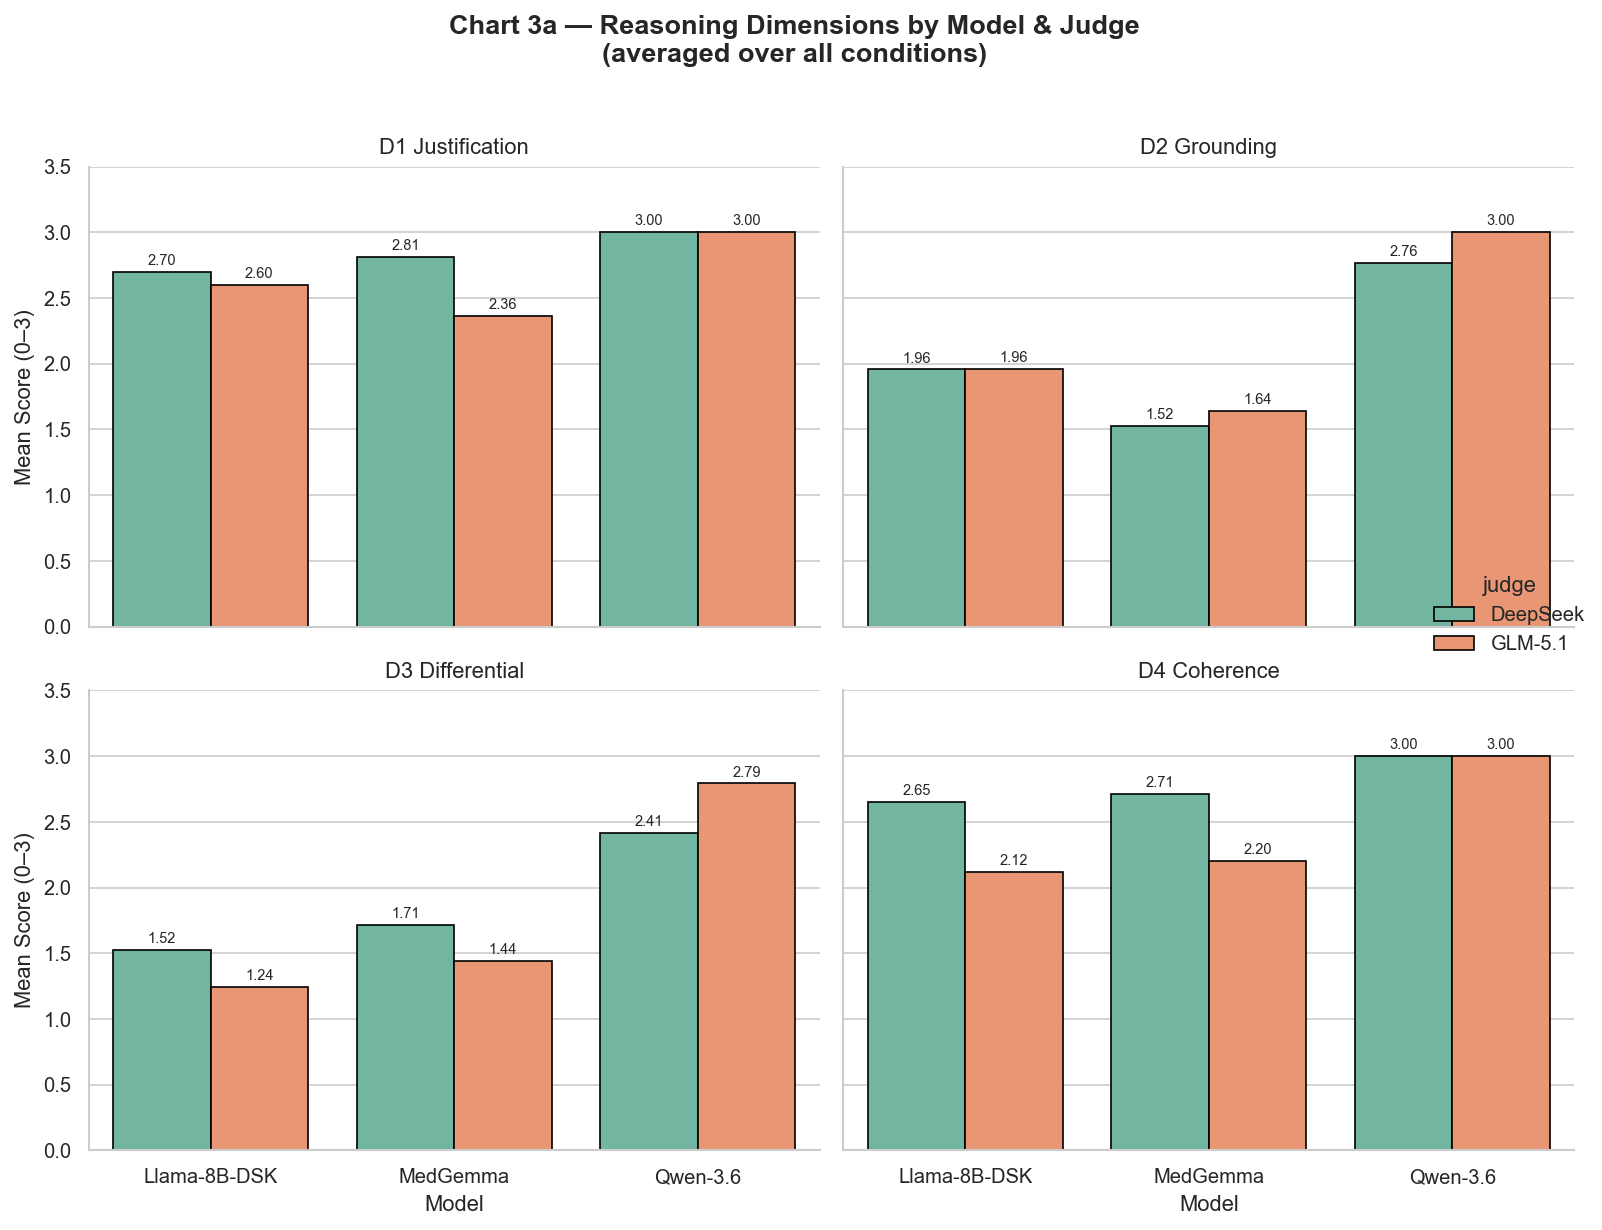

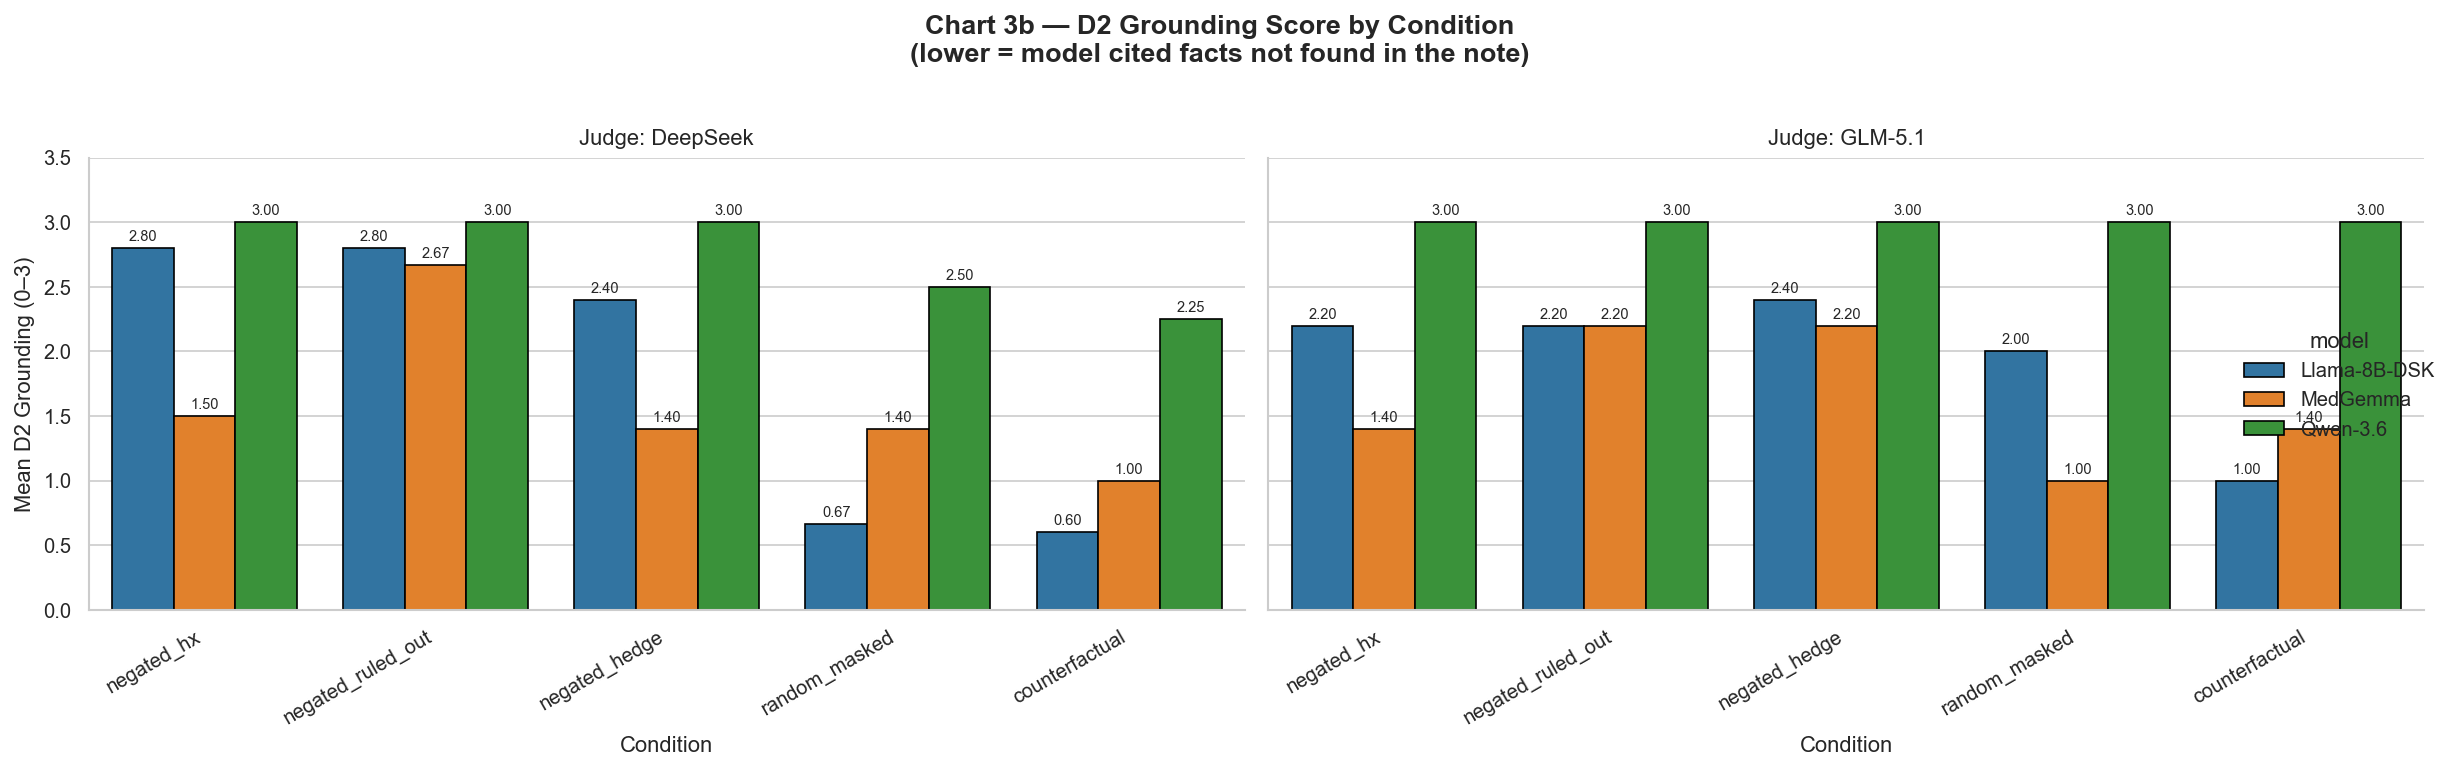

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# Chart 3: Reasoning Quality — D1 to D4 cross-model comparison
# ═══════════════════════════════════════════════════════════════════════════════

REASON_DIMS = ['d1_justification', 'd2_grounding', 'd3_differential', 'd4_coherence']
DIM_LABELS  = {
    'd1_justification': 'D1 Justification',
    'd2_grounding':     'D2 Grounding',
    'd3_differential':  'D3 Differential',
    'd4_coherence':     'D4 Coherence',
}
CONDITION_ORDER = ['negated_hx', 'negated_ruled_out', 'negated_hedge', 'random_masked', 'counterfactual']

# Keep only rows where all 4 dimension scores are valid (0–3)
df_r = df_reason.copy()
for col in REASON_DIMS:
    df_r = df_r[df_r[col].between(0, 3)]

# Reshape from wide (4 columns) to long (1 row per dimension)
# This lets seaborn put dimensions on the x-axis easily
df_melt = df_r.melt(
    id_vars=['model', 'judge', 'condition'],
    value_vars=REASON_DIMS,
    var_name='dimension',
    value_name='score'
)
df_melt['dimension'] = df_melt['dimension'].map(DIM_LABELS)

# Average score per (model, judge, dimension) across all conditions
dim_avg = df_melt.groupby(['model', 'judge', 'dimension'])['score'].mean().reset_index()

# ── 3a: All models side-by-side, one panel per dimension, colored by judge ────
g = sns.catplot(
    data=dim_avg,
    x='model', y='score', hue='judge', col='dimension',
    kind='bar', palette='Set2', edgecolor='black',
    order=MODEL_ORDER, col_wrap=2, height=4, aspect=1.2, legend_out=True
)
g.set_axis_labels('Model', 'Mean Score (0–3)')
g.set_titles('{col_name}')
g.set(ylim=(0, 3.5))
for ax in g.axes.flat:
    for bar_group in ax.containers:
        ax.bar_label(bar_group, fmt='%.2f', padding=2, fontsize=7)
g.figure.suptitle('Chart 3a — Reasoning Dimensions by Model & Judge\n(averaged over all conditions)',
                   fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── 3b: D2 Grounding by condition — lower score = model cited things not in the note ──
grounding_avg = df_r.groupby(['model', 'judge', 'condition'])['d2_grounding'].mean().reset_index()

g2 = sns.catplot(
    data=grounding_avg,
    x='condition', y='d2_grounding', hue='model',
    col='judge', kind='bar', palette='tab10', edgecolor='black',
    order=CONDITION_ORDER, height=5, aspect=1.5, legend_out=True
)
g2.set_axis_labels('Condition', 'Mean D2 Grounding (0–3)')
g2.set_titles('Judge: {col_name}')
g2.set(ylim=(0, 3.5))
g2.set_xticklabels(rotation=30, ha='right')
for ax in g2.axes.flat:
    for bar_group in ax.containers:
        ax.bar_label(bar_group, fmt='%.2f', padding=2, fontsize=7)
g2.figure.suptitle('Chart 3b — D2 Grounding Score by Condition\n(lower = model cited facts not found in the note)',
                    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


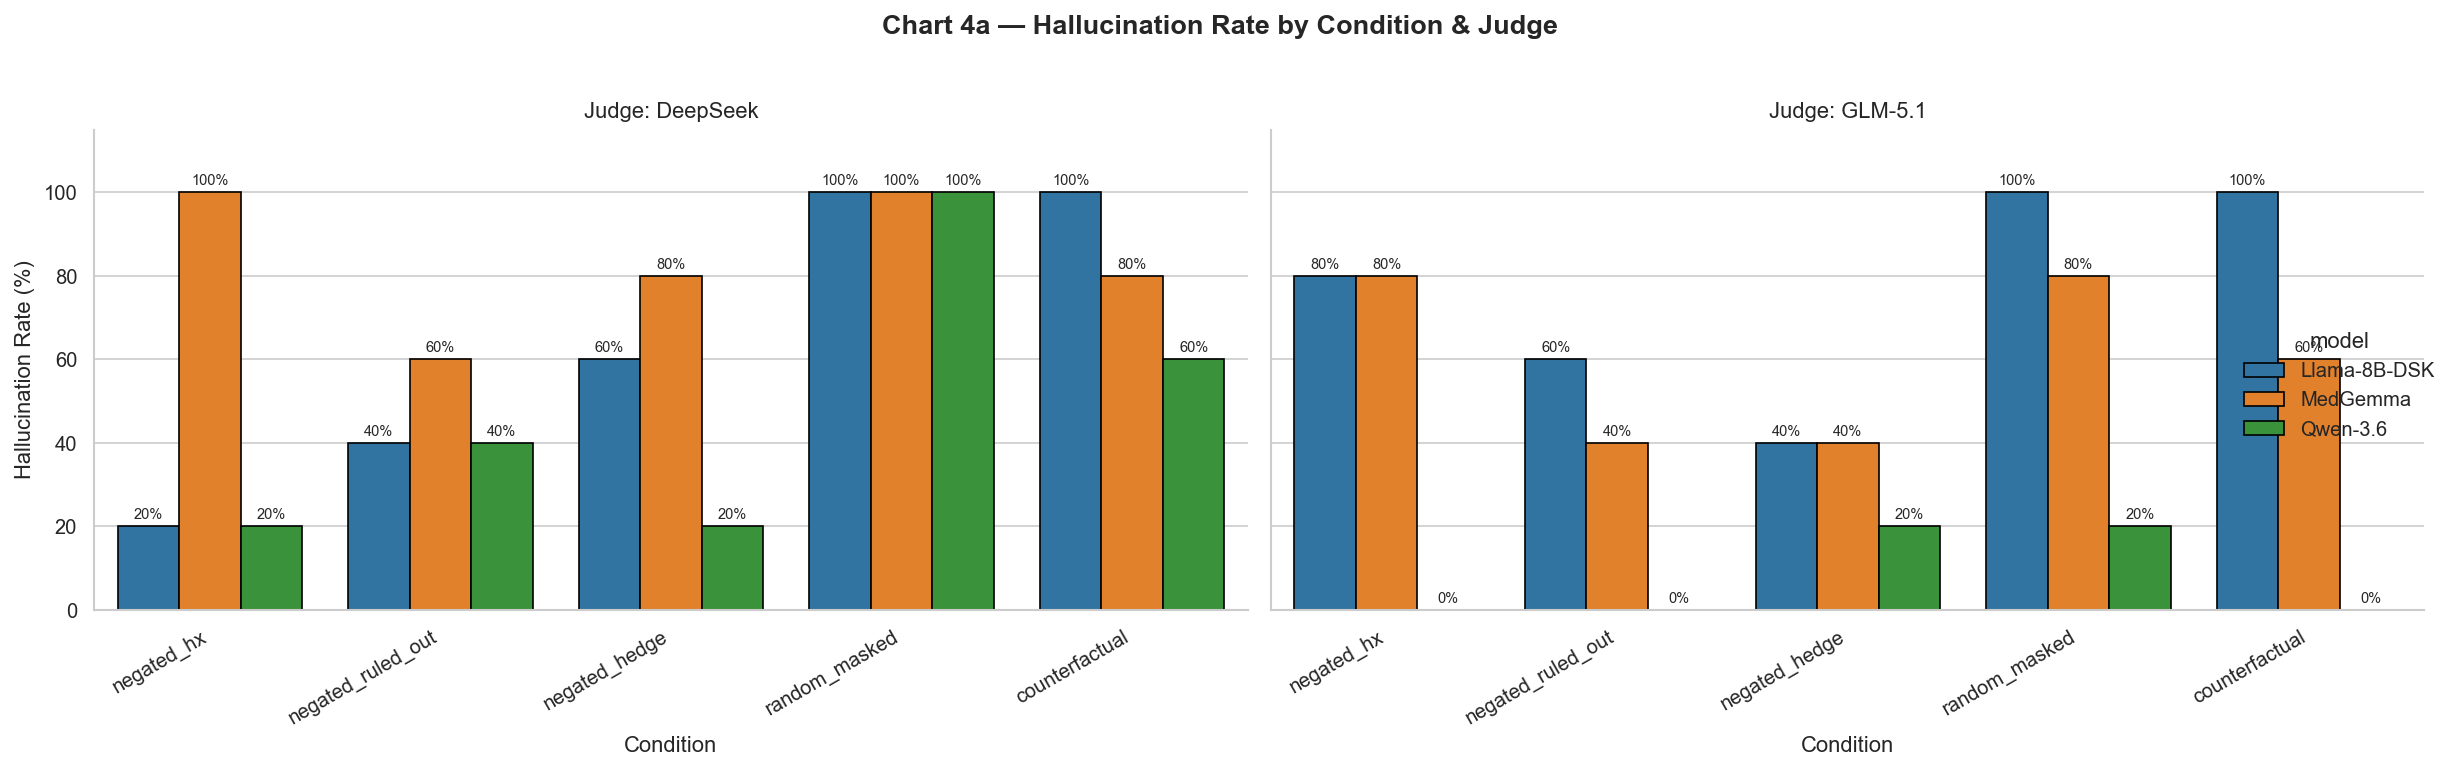

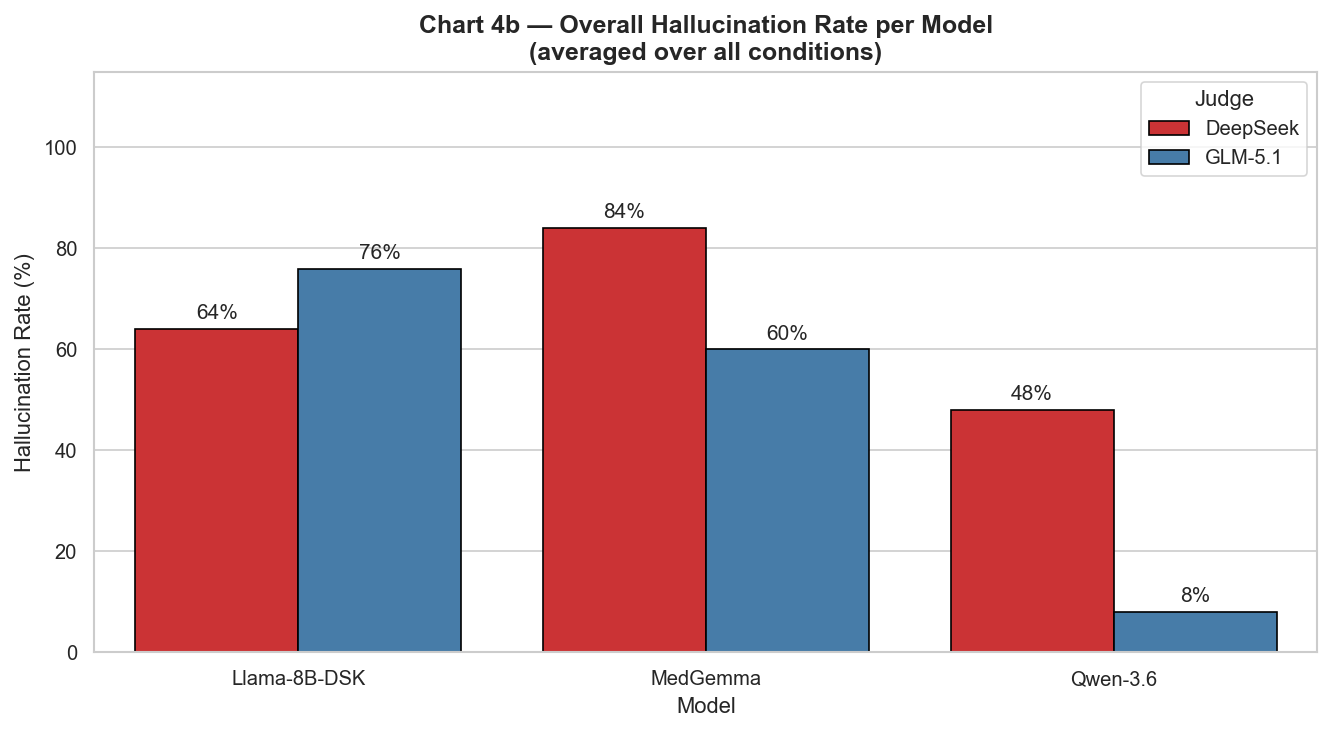

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# Chart 4: Hallucination Rate
# ═══════════════════════════════════════════════════════════════════════════════
# hallucination_flag = True means the judge detected hallucinated content
# (normalized from both GLM's boolean and DSK's string field in Cell 1)

CONDITION_ORDER = ['negated_hx', 'negated_ruled_out', 'negated_hedge', 'random_masked', 'counterfactual']

# .mean() on a True/False column gives the fraction that is True
# Multiply by 100 to get a percentage
hall_rate = (
    df_reason
    .groupby(['model', 'judge', 'condition'])['hallucination_flag']
    .mean()
    .reset_index()
)
hall_rate['hallucination_pct'] = hall_rate['hallucination_flag'] * 100

# ── 4a: Hallucination rate per condition, faceted by judge ────────────────────
g = sns.catplot(
    data=hall_rate,
    x='condition', y='hallucination_pct', hue='model',
    col='judge', kind='bar', palette='tab10', edgecolor='black',
    order=CONDITION_ORDER, height=5, aspect=1.5, legend_out=True
)
g.set_axis_labels('Condition', 'Hallucination Rate (%)')
g.set_titles('Judge: {col_name}')
g.set(ylim=(0, 115))
g.set_xticklabels(rotation=30, ha='right')
for ax in g.axes.flat:
    for bar_group in ax.containers:
        ax.bar_label(bar_group, fmt='%.0f%%', padding=2, fontsize=7)
g.figure.suptitle('Chart 4a — Hallucination Rate by Condition & Judge',
                   fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── 4b: Overall hallucination rate per model (averaged over all conditions) ────
hall_model = (
    df_reason
    .groupby(['model', 'judge'])['hallucination_flag']
    .mean()
    .reset_index()
)
hall_model['hallucination_pct'] = hall_model['hallucination_flag'] * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=hall_model, x='model', y='hallucination_pct', hue='judge',
            order=MODEL_ORDER, palette='Set1', edgecolor='black', ax=ax)
ax.set_title('Chart 4b — Overall Hallucination Rate per Model\n(averaged over all conditions)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Hallucination Rate (%)')
ax.set_xlabel('Model')
ax.set_ylim(0, 115)
ax.legend(title='Judge')
for bar_group in ax.containers:
    ax.bar_label(bar_group, fmt='%.0f%%', padding=3, fontsize=10)
plt.tight_layout()
plt.show()


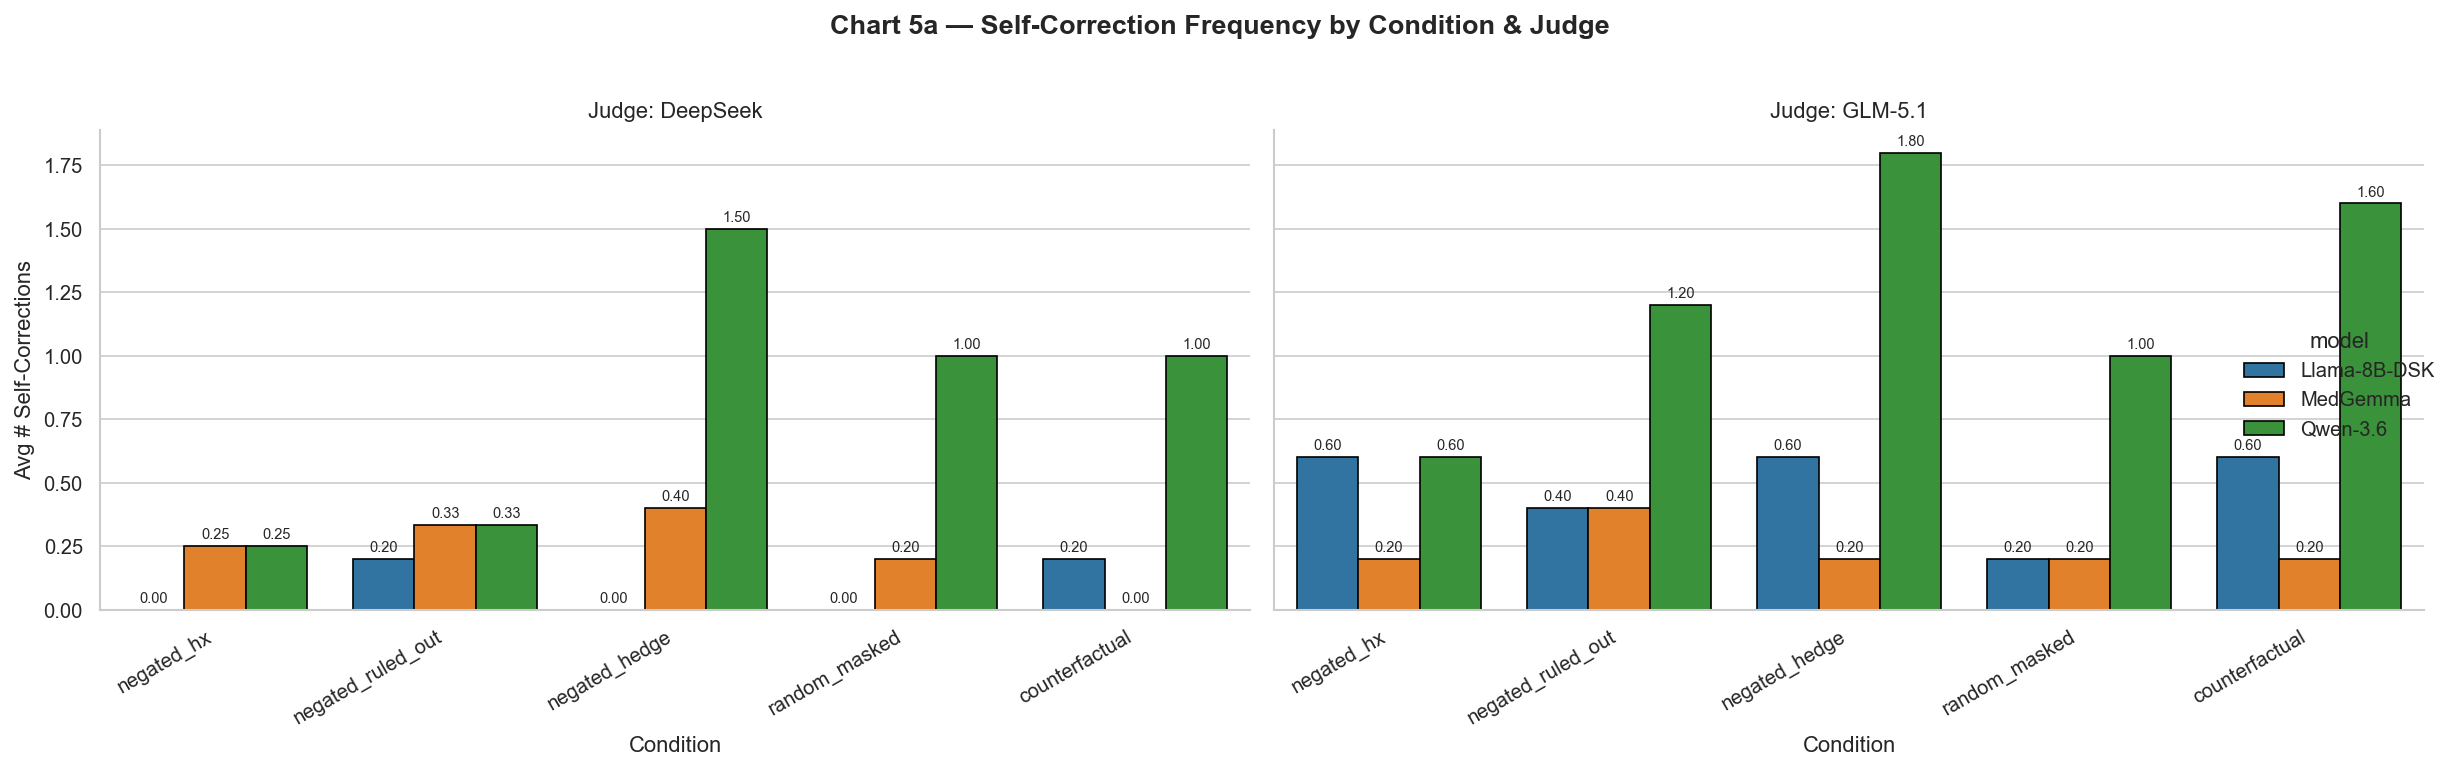

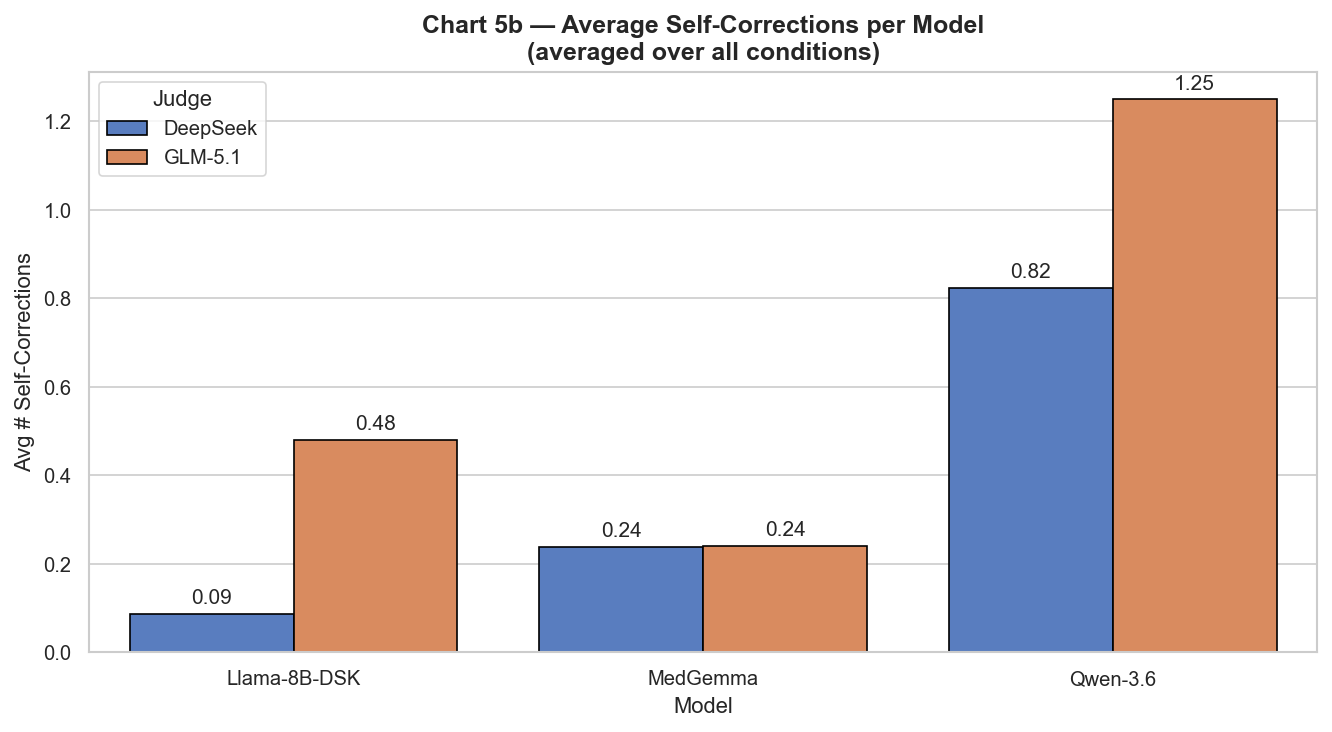

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# Chart 5: Self-Correction Frequency
# ═══════════════════════════════════════════════════════════════════════════════

CONDITION_ORDER = ['negated_hx', 'negated_ruled_out', 'negated_hedge', 'random_masked', 'counterfactual']

# Skip rows where num_self_correcting is negative (those are API error rows)
df_sc = df_reason[df_reason['num_self_correcting'] >= 0].copy()

# ── 5a: Average self-corrections per condition, faceted by judge ──────────────
sc_avg = df_sc.groupby(['model', 'judge', 'condition'])['num_self_correcting'].mean().reset_index()

g = sns.catplot(
    data=sc_avg,
    x='condition', y='num_self_correcting', hue='model',
    col='judge', kind='bar', palette='tab10', edgecolor='black',
    order=CONDITION_ORDER, height=5, aspect=1.5, legend_out=True
)
g.set_axis_labels('Condition', 'Avg # Self-Corrections')
g.set_titles('Judge: {col_name}')
g.set_xticklabels(rotation=30, ha='right')
for ax in g.axes.flat:
    for bar_group in ax.containers:
        ax.bar_label(bar_group, fmt='%.2f', padding=2, fontsize=7)
g.figure.suptitle('Chart 5a — Self-Correction Frequency by Condition & Judge',
                   fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── 5b: Overall average self-corrections per model ────────────────────────────
sc_model = df_sc.groupby(['model', 'judge'])['num_self_correcting'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=sc_model, x='model', y='num_self_correcting', hue='judge',
            order=MODEL_ORDER, palette='muted', edgecolor='black', ax=ax)
ax.set_title('Chart 5b — Average Self-Corrections per Model\n(averaged over all conditions)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Avg # Self-Corrections')
ax.set_xlabel('Model')
ax.legend(title='Judge')
for bar_group in ax.containers:
    ax.bar_label(bar_group, fmt='%.2f', padding=3, fontsize=10)
plt.tight_layout()
plt.show()


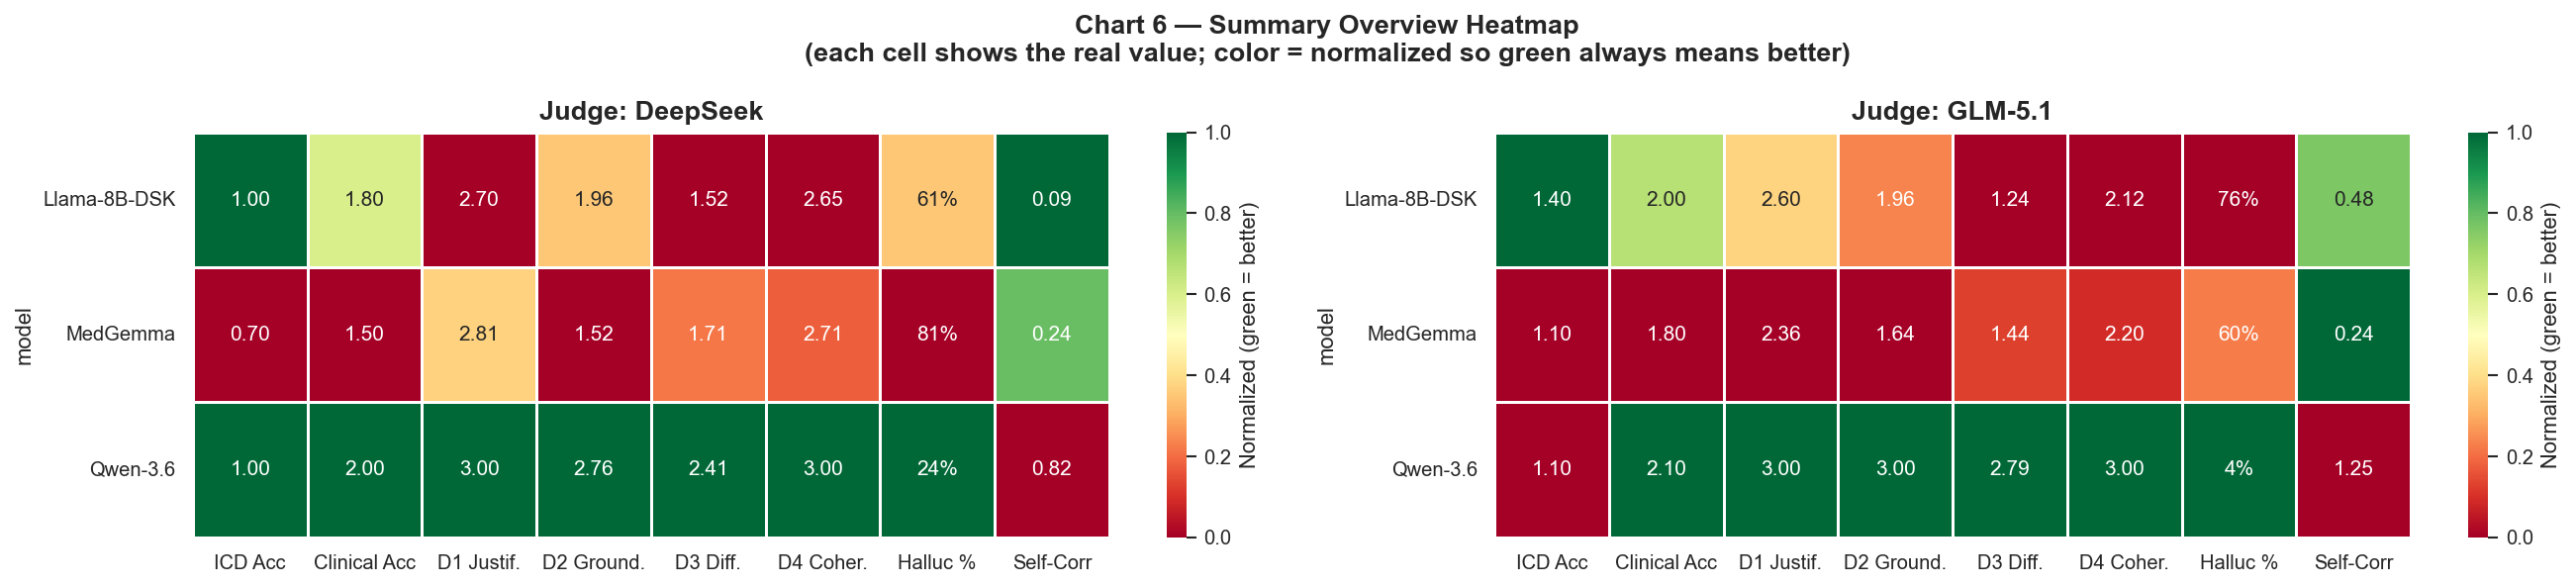

Summary table saved to: C:\Users\USER\Downloads\judge_summary_table.csv

       model    judge  d1_icd_accuracy  d1_clinical_accuracy  d1_justification  d2_grounding  d3_differential  d4_coherence  hallucination_pct  self_corrections
Llama-8B-DSK DeepSeek              1.0                   1.8          2.695652      1.956522         1.521739      2.652174          60.869565          0.086957
Llama-8B-DSK  GLM-5.1              1.4                   2.0          2.600000      1.960000         1.240000      2.120000          76.000000          0.480000
    MedGemma DeepSeek              0.7                   1.5          2.809524      1.523810         1.714286      2.714286          80.952381          0.238095
    MedGemma  GLM-5.1              1.1                   1.8          2.360000      1.640000         1.440000      2.200000          60.000000          0.240000
    Qwen-3.6 DeepSeek              1.0                   2.0          3.000000      2.764706         2.411765      3.00000

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# Chart 6: Summary Heatmap — one-glance overview of every metric per model
# ═══════════════════════════════════════════════════════════════════════════════

# ── Step 1: Collect all metric averages ──────────────────────────────────────

# Accuracy metrics (averaged over both shot conditions)
df_acc_clean = df_acc[df_acc['d1_icd_accuracy'].between(0, 3)].copy()
acc_metrics = (
    df_acc_clean
    .groupby(['model', 'judge'])[['d1_icd_accuracy', 'd1_clinical_accuracy']]
    .mean()
)

# Reasoning metrics (filter to valid scores only)
df_r = df_reason.copy()
for col in ['d1_justification', 'd2_grounding', 'd3_differential', 'd4_coherence']:
    df_r = df_r[df_r[col].between(0, 3)]

reason_metrics = (
    df_r
    .groupby(['model', 'judge'])[['d1_justification', 'd2_grounding', 'd3_differential', 'd4_coherence']]
    .mean()
)

hall_metrics = (
    df_r.groupby(['model', 'judge'])['hallucination_flag'].mean() * 100
).rename('hallucination_pct')

sc_metrics = (
    df_r[df_r['num_self_correcting'] >= 0]
    .groupby(['model', 'judge'])['num_self_correcting']
    .mean()
).rename('self_corrections')

# Combine all metrics into one table
all_metrics = acc_metrics.join(reason_metrics, how='outer')
all_metrics = all_metrics.join(hall_metrics, how='outer')
all_metrics = all_metrics.join(sc_metrics, how='outer')
all_metrics = all_metrics.reset_index()

# ── Step 2: Draw one heatmap per judge ───────────────────────────────────────
METRIC_COLS = [
    'd1_icd_accuracy', 'd1_clinical_accuracy',
    'd1_justification', 'd2_grounding', 'd3_differential', 'd4_coherence',
    'hallucination_pct', 'self_corrections',
]
COL_LABELS = [
    'ICD Acc', 'Clinical Acc',
    'D1 Justif.', 'D2 Ground.', 'D3 Diff.', 'D4 Coher.',
    'Halluc %', 'Self-Corr',
]
# For these two, lower is actually better — so we invert them when coloring
LOWER_IS_BETTER = {'Halluc %', 'Self-Corr'}

fig, axes = plt.subplots(1, 2, figsize=(18, 4))

for ax, judge in zip(axes, ['DeepSeek', 'GLM-5.1']):
    sub = all_metrics[all_metrics['judge'] == judge].set_index('model')
    sub = sub.reindex(MODEL_ORDER)          # keep consistent row order
    pivot = sub[METRIC_COLS].copy()
    pivot.columns = COL_LABELS

    # Normalize each column to 0–1 so colors are comparable across different scales
    # (e.g., hallucination% is 0–100 while accuracy is 0–3)
    pivot_norm = pivot.copy()
    for col in pivot.columns:
        col_min = pivot[col].min()
        col_max = pivot[col].max()
        col_range = col_max - col_min
        if col_range > 0:
            pivot_norm[col] = (pivot[col] - col_min) / col_range
        else:
            pivot_norm[col] = 0.5  # all same value — neutral

    # Invert columns where lower = better, so green always means "good"
    for col in LOWER_IS_BETTER:
        if col in pivot_norm.columns:
            pivot_norm[col] = 1 - pivot_norm[col]

    # Build annotation text: show the real number, or blank where data is missing
    annot_text = pivot.copy().astype(object)
    for col in annot_text.columns:
        for idx in annot_text.index:
            val = annot_text.loc[idx, col]
            if pd.isna(val):
                annot_text.loc[idx, col] = ''
            elif col == 'Halluc %':
                annot_text.loc[idx, col] = f'{val:.0f}%'
            else:
                annot_text.loc[idx, col] = f'{val:.2f}'

    sns.heatmap(
        pivot_norm,
        annot=annot_text,
        fmt='',                      # fmt='' because annot is already formatted strings
        mask=pivot.isna(),           # gray out cells with no data
        cmap='RdYlGn', vmin=0, vmax=1,
        linewidths=0.5, ax=ax,
        cbar_kws={'label': 'Normalized (green = better)'},
        annot_kws={'size': 10},
    )
    ax.set_title(f'Judge: {judge}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

fig.suptitle('Chart 6 — Summary Overview Heatmap\n(each cell shows the real value; color = normalized so green always means better)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# Export: save the raw summary numbers to a CSV
# ═══════════════════════════════════════════════════════════════════════════════
out_path = DOWNLOADS / "judge_summary_table.csv"
all_metrics.to_csv(out_path, index=False)
print(f"Summary table saved to: {out_path}")
print()
print(all_metrics.to_string(index=False))
